# 📡 Telecom Equipment Fault Detection: Predictive Maintenance with ML

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting equipment failures in telecommunications infrastructure to enable proactive maintenance  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting equipment failures using sensor telemetry data (temperature, rotational speed, torque, tool wear). The model enables **predictive maintenance** — identifying equipment likely to fail before outages occur, reducing downtime and maintenance costs.

### Government Policy Context
- **ACMA (Australian Communications and Media Authority)** — Network reliability standards, carrier licence conditions, regional connectivity obligations
- **Department of Infrastructure, Transport, Regional Development, Communications & the Arts** — Universal Service Guarantee, NBN reliability, regional/remote connectivity
- **Services Australia** — Digital service delivery depends on telecom uptime (myGov, Centrelink, Medicare online)
- **Defence / Home Affairs** — Critical communications infrastructure protection, resilience standards
- **Productivity Commission** — Telecommunications infrastructure investment, cost-benefit of predictive vs reactive maintenance

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Failure imminent (high confidence) | Schedule emergency maintenance, prepare spares | Field ops + NOC |
| Failure likely (moderate) | Prioritise in next maintenance window | Planning team |
| Healthy (high confidence) | Continue routine monitoring | Automated system |
| Healthy (low confidence) | Increase sensor polling frequency | Remote monitoring |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)
print(f"NumPy:   {np.__version__}")
print(f"Pandas:  {pd.__version__}")
print("=" * 60)


ENVIRONMENT READY
NumPy:   2.0.2
Pandas:  2.3.3


In [2]:
# === Dynamic path discovery ===
data_path = None
print("Scanning /kaggle/input for data files...")
print("-" * 50)
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
print("-" * 50)

if data_path is None:
    raise FileNotFoundError("No CSV file found — check dataset attachment")

print(f"\nUsing: {data_path}")

with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
print(f"Detected separator: '{sep}'")

df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


Scanning /kaggle/input for data files...
--------------------------------------------------
  Found: /kaggle/input/datasets/shivamb/machine-predictive-maintenance-classification/predictive_maintenance.csv
--------------------------------------------------

Using: /kaggle/input/datasets/shivamb/machine-predictive-maintenance-classification/predictive_maintenance.csv
Detected separator: ','

Loaded: 10,000 rows x 10 columns
Memory: 2151.4 KB


In [3]:
# === Initial data inspection ===
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | eg: {sample_val}")

print("\nFIRST 5 ROWS")
print("=" * 80)
df.head()


COLUMN SUMMARY
   0. UDI                                 | int64      | unique= 10000 | nulls=  0 | eg: 1
   1. Product ID                          | object     | unique= 10000 | nulls=  0 | eg: M14860
   2. Type                                | object     | unique=     3 | nulls=  0 | eg: M
   3. Air temperature [K]                 | float64    | unique=    93 | nulls=  0 | eg: 298.1
   4. Process temperature [K]             | float64    | unique=    82 | nulls=  0 | eg: 308.6
   5. Rotational speed [rpm]              | int64      | unique=   941 | nulls=  0 | eg: 1551
   6. Torque [Nm]                         | float64    | unique=   577 | nulls=  0 | eg: 42.8
   7. Tool wear [min]                     | int64      | unique=   246 | nulls=  0 | eg: 0
   8. Target                              | int64      | unique=     2 | nulls=  0 | eg: 0
   9. Failure Type                        | object     | unique=     6 | nulls=  0 | eg: No Failure

FIRST 5 ROWS


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## 2. Target Variable Identification & Analysis

In [4]:
# === Robust target detection ===
# This dataset has two targets: 'Target' (binary) and 'Failure Type' (multiclass)
# We use the binary 'Target' for failure prediction
target_candidates = ['Target', 'target', 'Machine failure', 'machine_failure',
                     'FraudFound_P', 'fraud_reported', 'Failure', 'failure',
                     'Class', 'class', 'Label', 'label']
target_col = None

for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback — last column: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target variable")

# Encode if string
if df[target_col].dtype == 'object':
    unique_vals = df[target_col].unique().tolist()
    fraud_keywords = ['Y', 'Yes', 'yes', 'TRUE', 'True', '1', 'Failure', 'failure', 'Failed']
    mapping = {v: (1 if v in fraud_keywords else 0) for v in unique_vals}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

print(f"\nTarget: '{target_col}'")
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))

assert df[target_col].nunique() >= 2, f"ERROR: Target has only {df[target_col].nunique()} class!"

imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")
if imbalance_ratio < 0.5:
    print("Class imbalance detected — stratified CV essential.")


Found target: 'Target'

Target: 'Target'

Distribution:
Target
0    9661
1     339
Name: count, dtype: int64

Proportions:
Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Imbalance ratio: 0.035
Class imbalance detected — stratified CV essential.


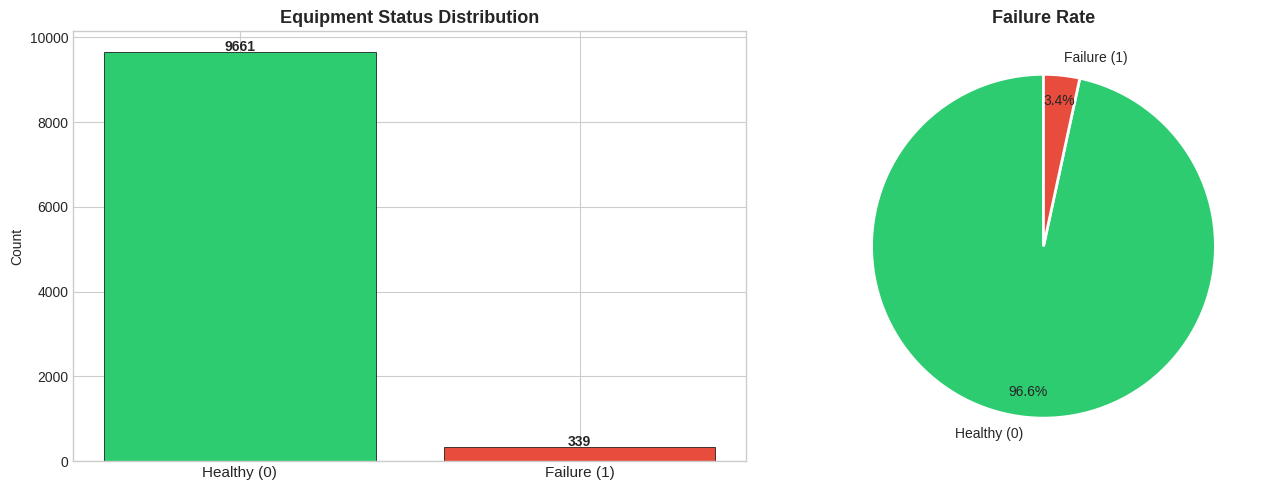

Infrastructure context: Even small failure rates (3-5%) cause major service disruptions.
Unplanned outages cost telcos ~$5K-$50K/hour depending on equipment criticality.


In [5]:
# === Target distribution visualisation ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['Healthy (0)', 'Failure (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))

axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Equipment Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Failure Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Infrastructure context: Even small failure rates (3-5%) cause major service disruptions.")
print("Unplanned outages cost telcos ~$5K-$50K/hour depending on equipment criticality.")


## 3. Exploratory Data Analysis

Key questions for infrastructure maintenance:
- Which sensor readings most strongly predict failure?
- Are there threshold effects (e.g., failure above certain temperature)?
- Do different product/equipment types fail at different rates?
- Are sensor readings correlated (multicollinearity)?


Numeric features (6): ['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


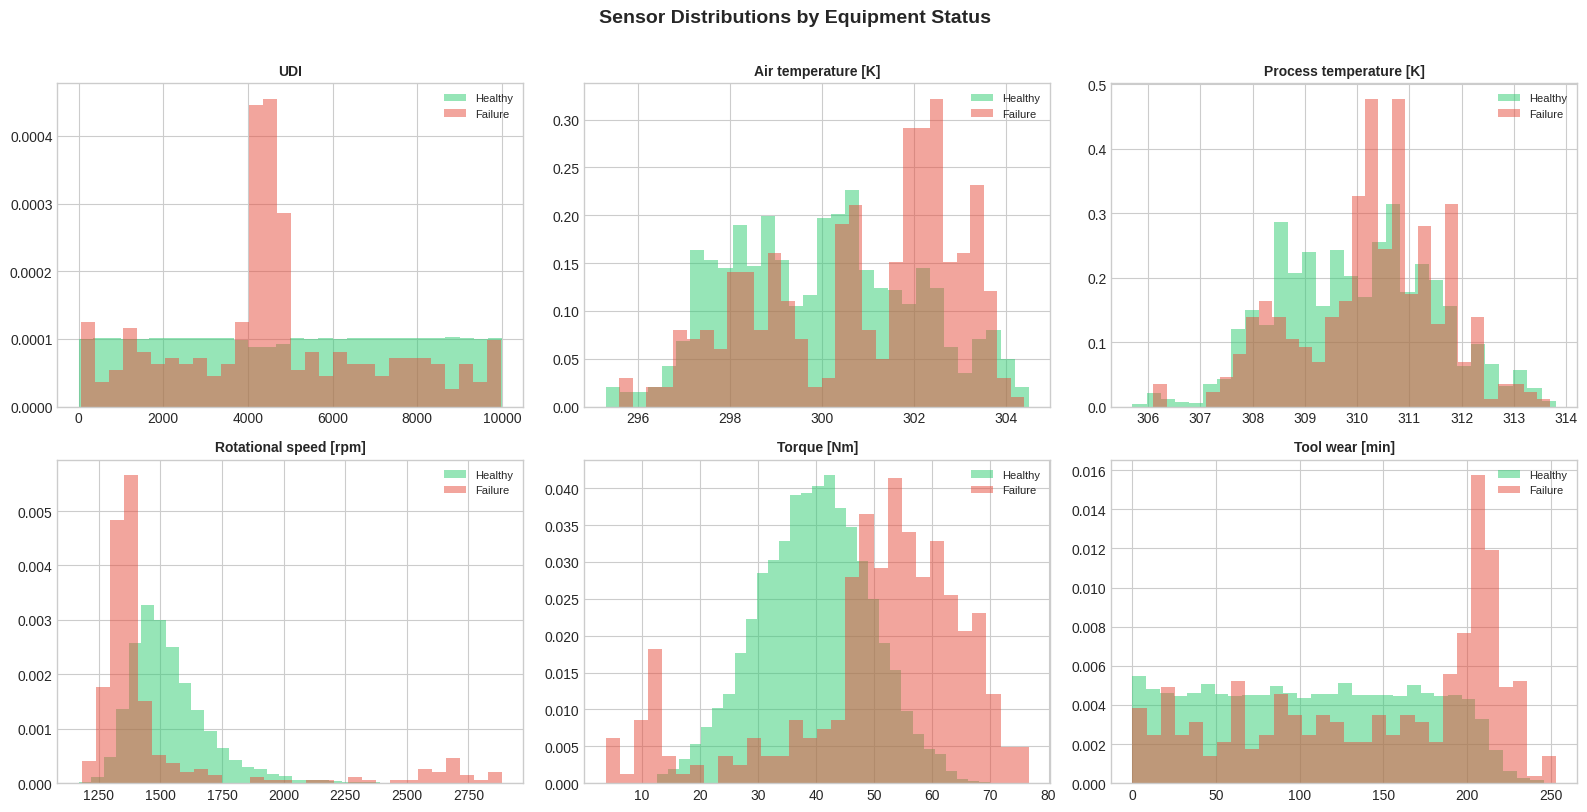

In [6]:
# === Numeric feature distributions by failure status ===
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
# Drop ID-like columns
numeric_cols = [c for c in numeric_cols if c.lower() not in ['uid', 'id', 'index']]

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_cols_p = 3
    n_rows_p = (len(plot_cols) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        for label, color, name in zip(sorted(df[target_col].unique()),
                                       ['#2ecc71', '#e74c3c'], ['Healthy', 'Failure']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                ax.hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Sensor Distributions by Equipment Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()


Categorical features: ['Type', 'Failure Type']


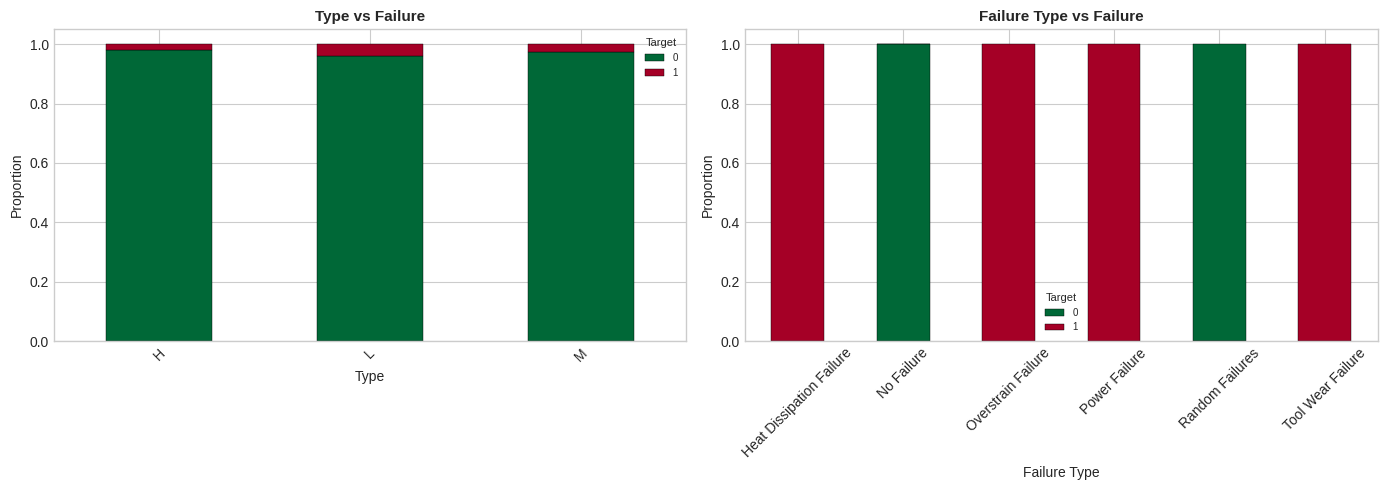

In [7]:
# === Categorical feature analysis ===
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 20 and 'id' not in c.lower()
            and 'product' not in c.lower().replace('product id', '')]

# Also check 'Type' column specifically and 'Failure Type'
special_cats = [c for c in df.columns if c in ['Type', 'Failure Type'] and c != target_col]
cat_cols = list(set(cat_cols + special_cats))

print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:4]
    n_cols_p = min(2, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r',
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Failure', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title=target_col, fontsize=7, title_fontsize=8)
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No categorical features to plot.")


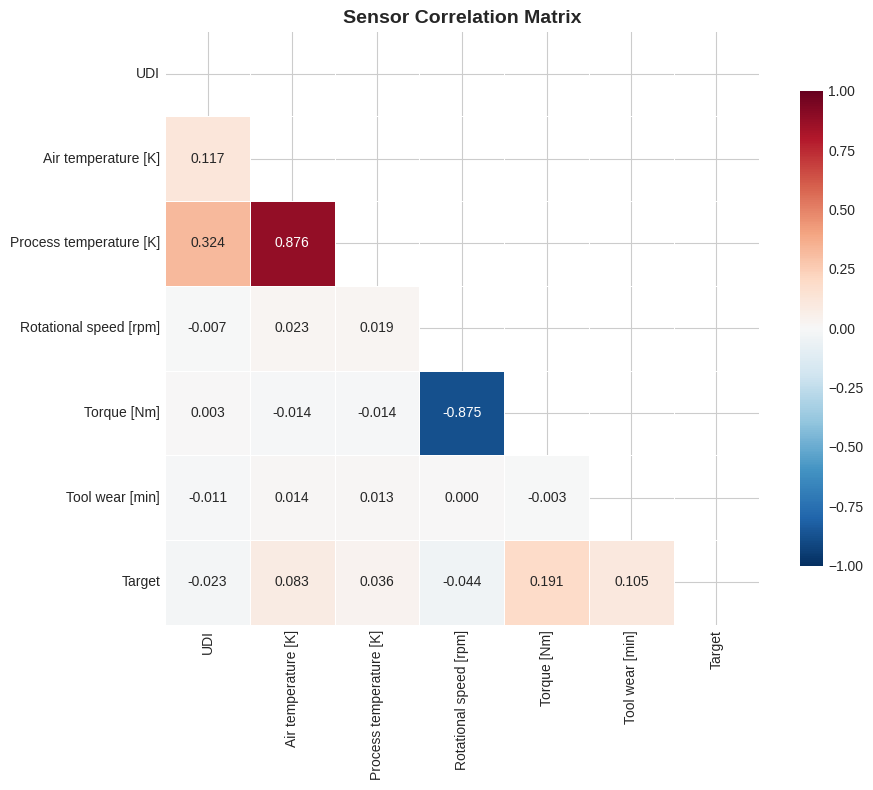

Correlations with failure (absolute):
  Torque [Nm]                         +0.1913
  Tool wear [min]                     +0.1054
  Air temperature [K]                 +0.0826
  Rotational speed [rpm]              -0.0442
  Process temperature [K]             +0.0359
  UDI                                 -0.0229


In [8]:
# === Correlation heatmap ===
if len(numeric_cols) > 1:
    corr_cols = numeric_cols + [target_col]
    corr = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8}, ax=ax)
    ax.set_title('Sensor Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with failure (absolute):")
    for feat, val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:35s} {direction}{val:.4f}")


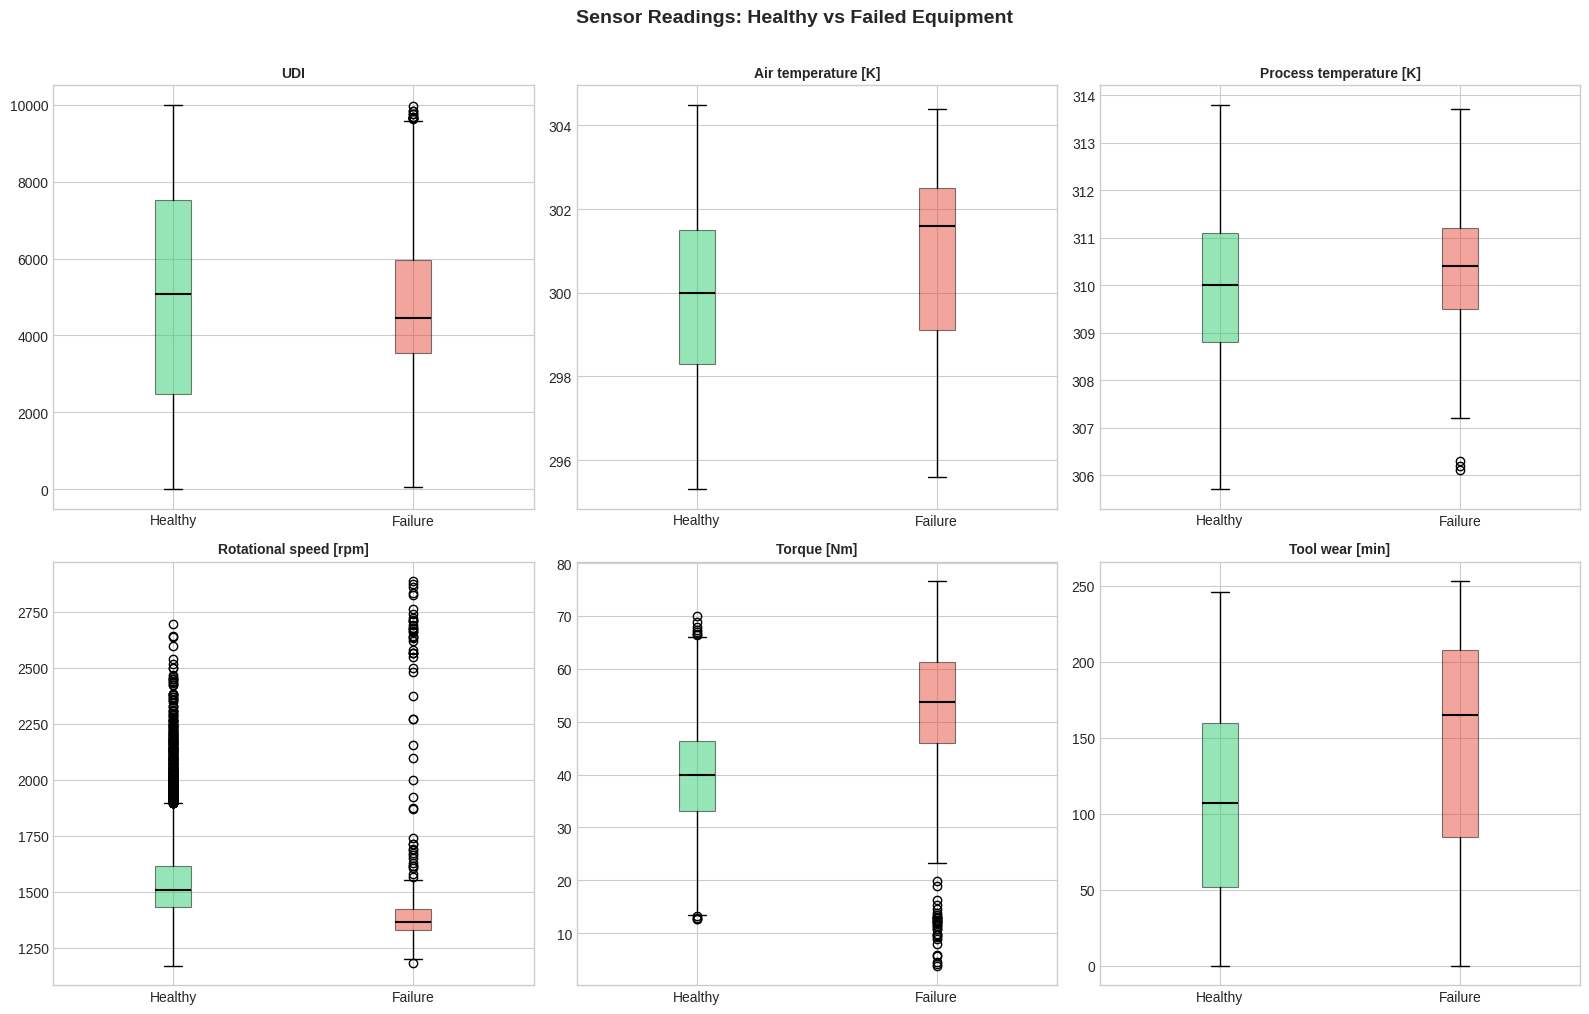

In [9]:
# === Box plots by failure status ===
plot_box = numeric_cols[:6]
if len(plot_box) > 0:
    n_cols_p = 3
    n_rows_p = (len(plot_box) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 5 * n_rows_p))
    axes = axes.flatten()

    for i, col in enumerate(plot_box):
        data_plot = [df[df[target_col] == v][col].dropna() for v in sorted(df[target_col].unique())]
        box_labels = ['Healthy', 'Failure'] if len(data_plot) == 2 else [str(v) for v in sorted(df[target_col].unique())]
        bp = axes[i].boxplot(data_plot, labels=box_labels, patch_artist=True,
                              boxprops=dict(linewidth=0.8), medianprops=dict(color='black', linewidth=1.5))
        for j, box in enumerate(bp['boxes']):
            box.set_facecolor(['#2ecc71', '#e74c3c'][j] if j < 2 else '#3498db')
            box.set_alpha(0.5)
        axes[i].set_title(col, fontsize=10, fontweight='bold')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Sensor Readings: Healthy vs Failed Equipment', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4. Feature Engineering & Preprocessing

Predictive maintenance benefits from physics-informed features:
- **Temperature differential** — gap between air and process temperature indicates heat dissipation issues
- **Power output** — derived from torque × rotational speed
- **Wear severity** — tool wear relative to equipment type thresholds
- **Operating envelope** — is equipment running outside normal parameters?


In [10]:
# === Preprocessing pipeline ===
df_model = df.copy()

# Replace '?' with NaN
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_replaced = (df_model[col] == '?').sum()
        if n_replaced > 0:
            df_model[col] = df_model[col].replace('?', np.nan)
            print(f"  Replaced {n_replaced} '?' in '{col}'")

# Drop ID columns and Failure Type (would leak target info)
drop_cols = []
for col in df_model.columns:
    if col.lower() in ['uid', 'id', 'index', 'product id', 'productid']:
        drop_cols.append(col)
    if col == 'Failure Type':
        drop_cols.append(col)
        print(f"  Dropping 'Failure Type' (leaks target)")

# Check for 'Product ID' with space
if 'Product ID' in df_model.columns:
    drop_cols.append('Product ID')

drop_cols = list(set(drop_cols))
if drop_cols:
    print(f"\nDropping: {drop_cols}")
    df_model.drop(columns=drop_cols, inplace=True)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes -> {list(le.classes_)}")

# Separate features and target
X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Verify
print(f"\nTarget classes: {np.unique(y)} counts: {dict(zip(*np.unique(y, return_counts=True)))}")
assert len(np.unique(y)) >= 2, "Target must have at least 2 classes!"

# Median imputation
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values with median...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")


  Dropping 'Failure Type' (leaks target)

Dropping: ['Product ID', 'Failure Type']
  Encoded 'Type': 3 classes -> ['H', 'L', 'M']

Target classes: [0 1] counts: {np.int64(0): np.int64(9661), np.int64(1): np.int64(339)}

Feature matrix: (10000, 7)


In [11]:
# === Domain-driven feature engineering ===
feature_names = X.columns.tolist()
composites_added = []

# Temperature differential (heat dissipation indicator)
air_temp = [c for c in feature_names if 'air' in c.lower() and 'temp' in c.lower()]
proc_temp = [c for c in feature_names if 'process' in c.lower() and 'temp' in c.lower()]
if air_temp and proc_temp:
    X['temp_differential'] = X[proc_temp[0]] - X[air_temp[0]]
    composites_added.append('temp_differential')
    print(f"Created 'temp_differential' = {proc_temp[0]} - {air_temp[0]}")

# Power output (torque * rotational speed)
torque_cols = [c for c in feature_names if 'torque' in c.lower()]
speed_cols = [c for c in feature_names if 'rotational' in c.lower() or 'speed' in c.lower() or 'rpm' in c.lower()]
if torque_cols and speed_cols:
    X['power_output'] = X[torque_cols[0]] * X[speed_cols[0]] / 9.5488  # Convert to watts
    composites_added.append('power_output')
    print(f"Created 'power_output' = {torque_cols[0]} * {speed_cols[0]} / 9.5488")

# Tool wear severity (normalised)
wear_cols = [c for c in feature_names if 'wear' in c.lower() or 'tool' in c.lower()]
if wear_cols:
    max_wear = X[wear_cols[0]].max()
    if max_wear > 0:
        X['wear_severity'] = X[wear_cols[0]] / max_wear
        composites_added.append('wear_severity')
        print(f"Created 'wear_severity' (normalised {wear_cols[0]})")

# Torque-wear interaction (overstrain indicator)
if torque_cols and wear_cols:
    X['torque_wear_interaction'] = X[torque_cols[0]] * X[wear_cols[0]]
    composites_added.append('torque_wear_interaction')
    print(f"Created 'torque_wear_interaction'")

# Operating outside normal envelope
if speed_cols:
    speed_mean = X[speed_cols[0]].mean()
    speed_std = X[speed_cols[0]].std()
    X['speed_anomaly'] = ((X[speed_cols[0]] < speed_mean - 2*speed_std) |
                           (X[speed_cols[0]] > speed_mean + 2*speed_std)).astype(int)
    composites_added.append('speed_anomaly')
    print(f"Created 'speed_anomaly' (>2 std from mean)")

if composites_added:
    print(f"\nTotal engineered features: {len(composites_added)}")
else:
    print("\nNo domain features matched.")

print(f"Final feature count: {X.shape[1]}")


Created 'temp_differential' = Process temperature [K] - Air temperature [K]
Created 'power_output' = Torque [Nm] * Rotational speed [rpm] / 9.5488
Created 'wear_severity' (normalised Tool wear [min])
Created 'torque_wear_interaction'
Created 'speed_anomaly' (>2 std from mean)

Total engineered features: 5
Final feature count: 12


## 5. Model Training & Cross-Validation

Four-model comparison using manual 3-fold stratified CV:
1. **Logistic Regression** — interpretable baseline for maintenance rules
2. **Random Forest** — captures sensor threshold effects
3. **XGBoost** — gradient boosting benchmark
4. **LightGBM** — fast inference for real-time monitoring

ROC-AUC as primary metric — ranking failure probability enables priority-based maintenance scheduling.


In [12]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [13]:
# === Manual 3-Fold Stratified CV ===
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, random_state=42, eval_metric='logloss',
        use_label_encoder=False, verbosity=0, n_jobs=-1
    )

if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=100, random_state=42, verbose=-1, n_jobs=-1,
        force_col_wise=True
    )

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        
        fold_preds[val_idx] = y_pred
        fold_proba[val_idx] = y_prob
        
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}")
    
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba
    }
    print(f"  -- Mean Acc: {np.mean(fold_acc):.4f} +/- {np.std(fold_acc):.4f}")
    print(f"  -- Mean F1:  {np.mean(fold_f1):.4f} +/- {np.std(fold_f1):.4f}")
    print(f"  -- Mean AUC: {np.mean(fold_auc):.4f} +/- {np.std(fold_auc):.4f}")
    print(f"  -- Time:     {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9706  F1=0.3378  AUC=0.9096  Prec=0.7143  Rec=0.2212
  Fold 2: Acc=0.9694  F1=0.3544  AUC=0.9187  Prec=0.6222  Rec=0.2478
  Fold 3: Acc=0.9712  F1=0.4074  AUC=0.9301  Prec=0.6735  Rec=0.2920
  -- Mean Acc: 0.9704 +/- 0.0007
  -- Mean F1:  0.3666 +/- 0.0297
  -- Mean AUC: 0.9194 +/- 0.0084
  -- Time:     3.76s

Training: Random Forest
  Fold 1: Acc=0.9904  F1=0.8519  AUC=0.9621  Prec=0.8932  Rec=0.8142
  Fold 2: Acc=0.9937  F1=0.8986  AUC=0.9715  Prec=0.9894  Rec=0.8230
  Fold 3: Acc=0.9913  F1=0.8638  AUC=0.9684  Prec=0.9200  Rec=0.8142
  -- Mean Acc: 0.9918 +/- 0.0014
  -- Mean F1:  0.8714 +/- 0.0198
  -- Mean AUC: 0.9673 +/- 0.0039
  -- Time:     2.24s

Training: XGBoost
  Fold 1: Acc=0.9856  F1=0.7857  AUC=0.9646  Prec=0.7928  Rec=0.7788
  Fold 2: Acc=0.9895  F1=0.8309  AUC=0.9753  Prec=0.9149  Rec=0.7611
  Fold 3: Acc=0.9880  F1=0.8148  AUC=0.9817  Prec=0.8544  Rec=0.7788
  -- Mean Acc: 0.9877 +/- 0.0016
  -- Mean F1:  0.8105 +/- 0.018

## 6. Model Comparison & Selection

In [14]:
summary_rows = []
for model_name, res in results.items():
    summary_rows.append({
        'Model': model_name,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}",
        'Time (s)': f"{res['time']:.2f}",
        'AUC_val': res['auc_mean']
    })

summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']

print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time (s)']].to_string(index=False))
print("=" * 100)
print(f"\nBest model (by AUC): {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier Time (s)
           LightGBM 0.9898 +/- 0.0008 0.8394 +/- 0.0096 0.9776 +/- 0.0016 0.0092     0.57
            XGBoost 0.9877 +/- 0.0016 0.8105 +/- 0.0187 0.9738 +/- 0.0070 0.0105     0.53
      Random Forest 0.9918 +/- 0.0014 0.8714 +/- 0.0198 0.9673 +/- 0.0039 0.0081     2.24
Logistic Regression 0.9704 +/- 0.0007 0.3666 +/- 0.0297 0.9194 +/- 0.0084 0.0235     3.76

Best model (by AUC): LightGBM


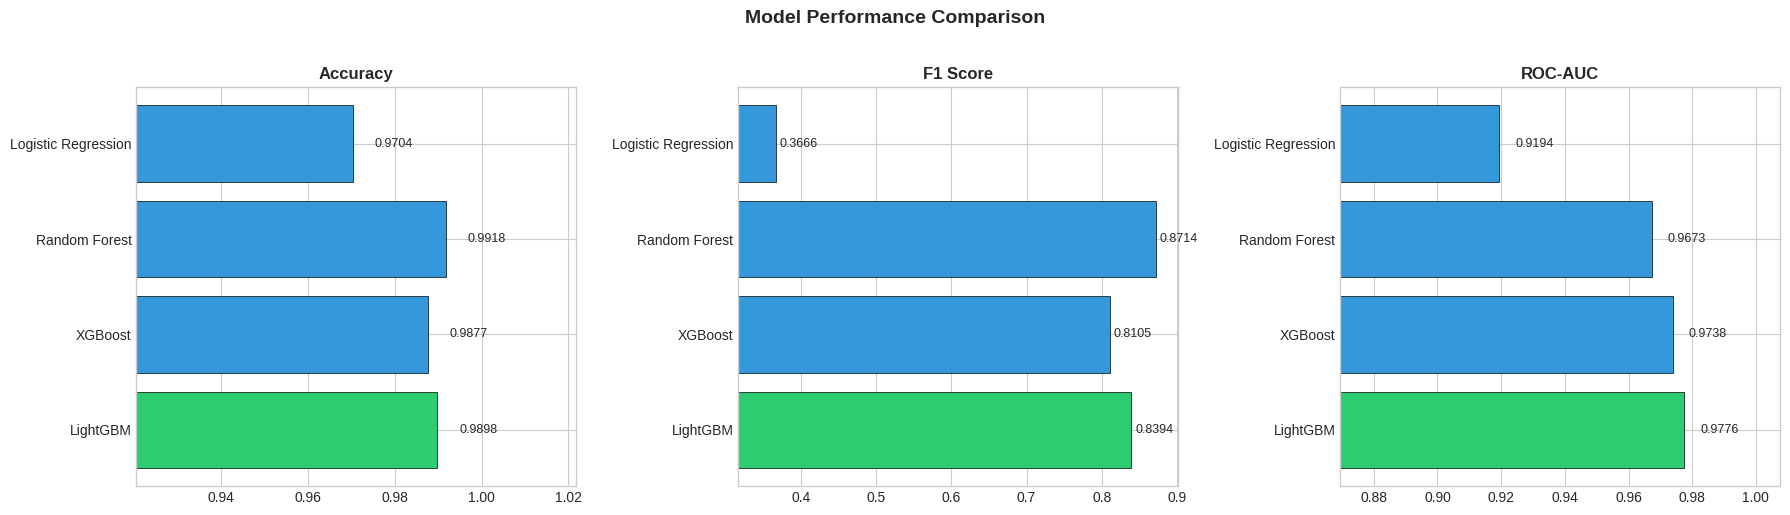

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = [r['Model'] for _, r in summary_df.iterrows()]
acc_vals = [results[m]['accuracy_mean'] for m in model_names]
f1_vals = [results[m]['f1_mean'] for m in model_names]
auc_vals = [results[m]['auc_mean'] for m in model_names]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]

for ax, vals, title in zip(axes, [acc_vals, f1_vals, auc_vals], ['Accuracy', 'F1 Score', 'ROC-AUC']):
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Error Analysis & Threshold Tuning

For equipment maintenance:
- **False negatives** (missed failures) = unplanned outages, service disruption, safety risk
- **False positives** (unnecessary maintenance) = wasted resources, unnecessary downtime
- Threshold tuning balances maintenance budget vs outage risk


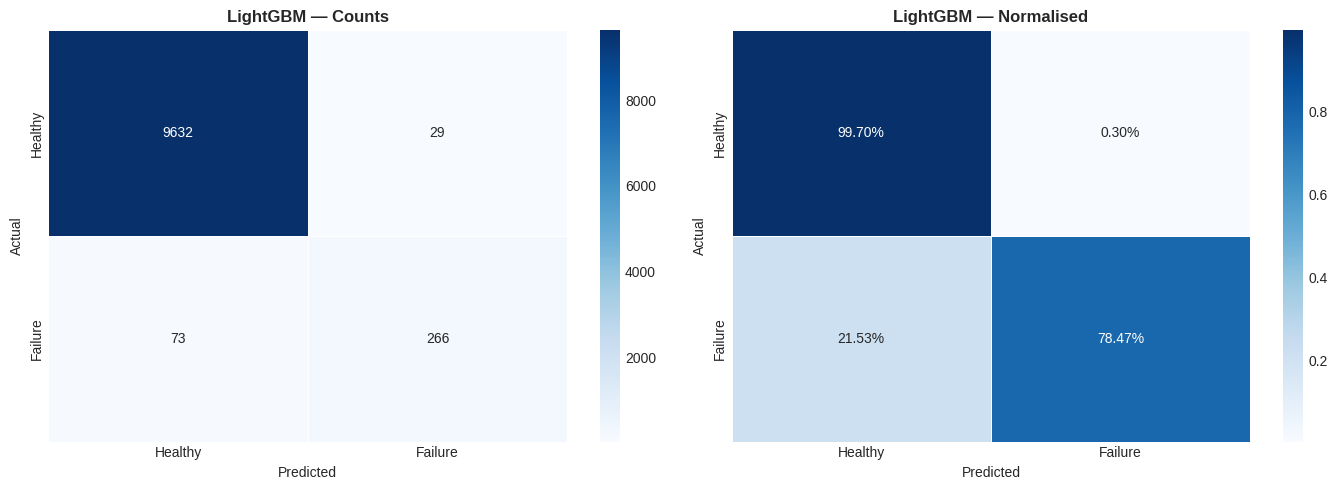


CLASSIFICATION REPORT — LightGBM
              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99      9661
     Failure       0.90      0.78      0.84       339

    accuracy                           0.99     10000
   macro avg       0.95      0.89      0.92     10000
weighted avg       0.99      0.99      0.99     10000



In [16]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']

cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Healthy', 'Failure']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels,
            yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels,
            yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCLASSIFICATION REPORT — {best_model_name}")
print("=" * 60)
print(classification_report(y, best_preds, target_names=cm_labels))


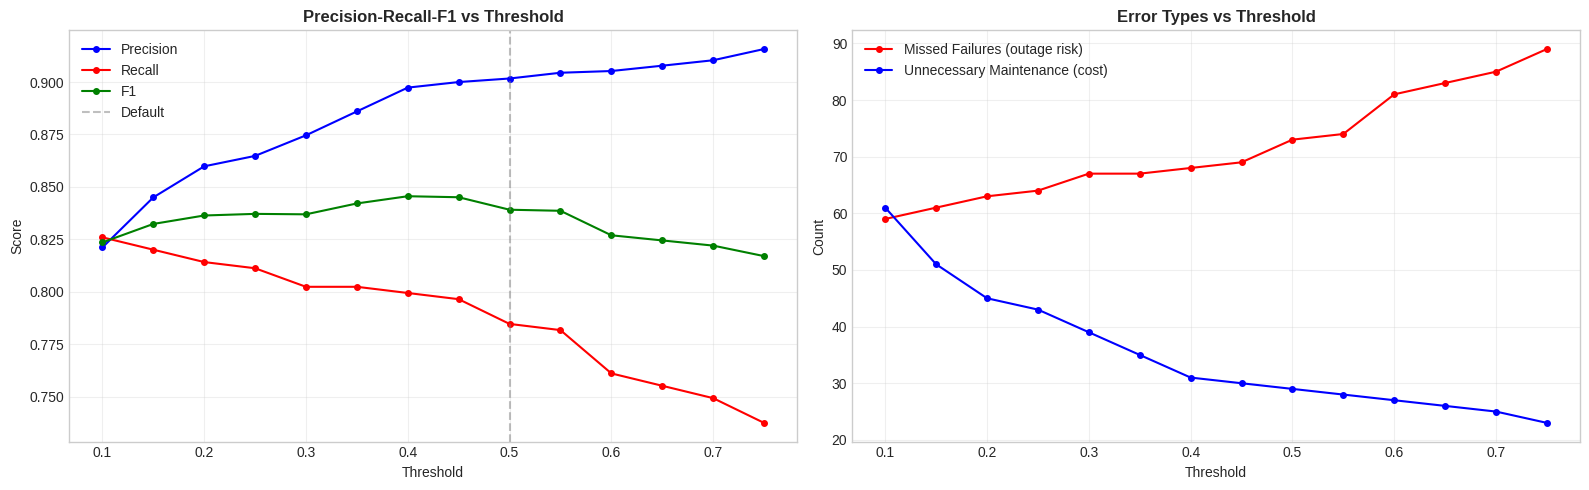


Optimal threshold (F1): 0.40
Precision=0.8974, Recall=0.7994, F1=0.8456


In [17]:
# === Threshold tuning ===
thresholds = np.arange(0.10, 0.80, 0.05)
thresh_results = []

for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    prec = precision_score(y, y_t, zero_division=0)
    rec = recall_score(y, y_t, zero_division=0)
    f1 = f1_score(y, y_t, zero_division=0)
    fn = ((y == 1) & (y_t == 0)).sum()
    fp = ((y == 0) & (y_t == 1)).sum()
    thresh_results.append({
        'Threshold': thresh, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'Missed Failure (FN)': fn, 'Unnecessary Maint (FP)': fp
    })

thresh_df = pd.DataFrame(thresh_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', label='Recall', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', label='F1', ms=4)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Failure (FN)'], 'r-o', label='Missed Failures (outage risk)', ms=4)
axes[1].plot(thresh_df['Threshold'], thresh_df['Unnecessary Maint (FP)'], 'b-o', label='Unnecessary Maintenance (cost)', ms=4)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"Precision={thresh_df.loc[best_f1_idx, 'Precision']:.4f}, "
      f"Recall={thresh_df.loc[best_f1_idx, 'Recall']:.4f}, "
      f"F1={thresh_df.loc[best_f1_idx, 'F1']:.4f}")


## 8. Feature Importance & Policy Insights

Understanding which sensor readings drive failure predictions:
- **Field engineers** — which readings to monitor most closely
- **Network planners** — equipment specification and procurement decisions
- **Regulators** — validating maintenance compliance with licence conditions


Feature importance from: LightGBM


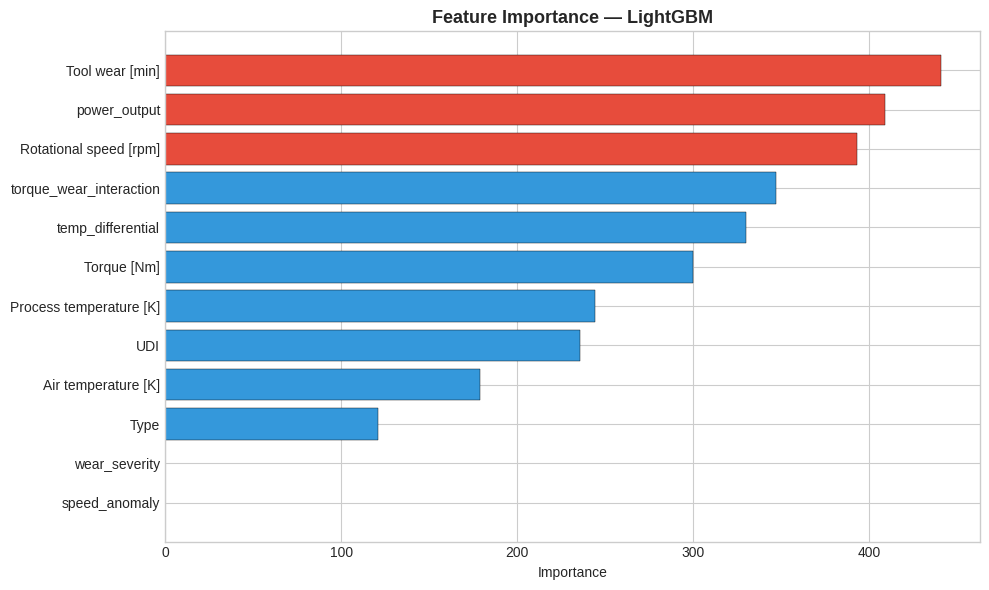


TOP 5 PREDICTIVE FEATURES
  Tool wear [min]                      441.0000
  power_output                         409.0000
  Rotational speed [rpm]               393.0000
  torque_wear_interaction              347.0000
  temp_differential                    330.0000


In [18]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}

if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    print(f"Feature importance from: {best_tree}")
    
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    
    feat_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': full_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db'
                  for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    top5 = feat_imp.tail(5).iloc[::-1]
    print("\nTOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


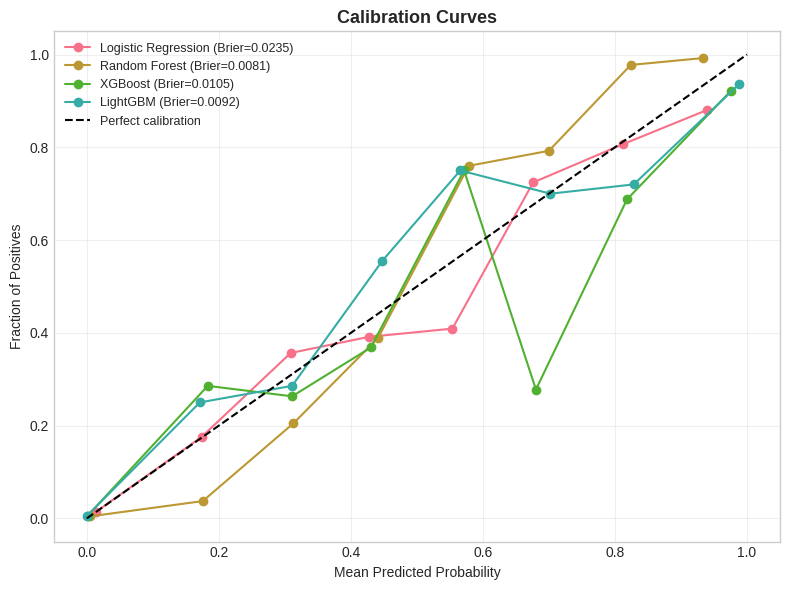

In [19]:
# === Calibration curve ===
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in results:
    prob_true, prob_pred = calibration_curve(y, results[model_name]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{model_name} (Brier={results[model_name]['brier_mean']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Deployment Readiness & Production Considerations

In [20]:
best_res = results[best_model_name]

print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"")
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print(f"")
print("=" * 60)

checks = {
    'AUC > 0.70': best_res['auc_mean'] > 0.70,
    'F1 > 0.30': best_res['f1_mean'] > 0.30,
    'Brier < 0.10': best_res['brier_mean'] < 0.10,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}

print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")

print("-" * 50)
if all_pass:
    print("  MODEL APPROVED FOR PILOT DEPLOYMENT")
else:
    print("  SOME CHECKS FAILED — Review before deployment")


DEPLOYMENT READINESS SUMMARY

  Recommended model:    LightGBM
  ROC-AUC:              0.9776
  F1:                   0.8394
  Precision:            0.9037
  Recall:               0.7847
  Brier Score:          0.0092
  Training time:        0.6s
  Feature count:        12
  Dataset rows:         10,000
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.40


PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.70
  [pass] F1 > 0.30
  [pass] Brier < 0.10
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [21]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: IoT sensors on telecom equipment (SNMP, telemetry APIs)
   Ingestion: Azure IoT Hub -> Event Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric Lakehouse medallion (bronze/silver/gold)
   Schedule: Real-time streaming (1-min aggregation) + hourly batch

2. MODEL SERVING
   Framework: MLflow model registry on Databricks / Fabric
   Endpoint: Azure ML real-time endpoint (per-device scoring)
   Latency: <100ms per prediction
   Batch: Hourly scoring of all monitored equipment

3. INTEGRATION POINTS
   NOC dashboard: Power BI real-time (equipment health heatmap)
   Ticketing: Auto-create maintenance tickets in ServiceNow
   Alerting: PagerDuty / OpsGenie for critical failure predictions
   Field dispatch: Optimised scheduling based on failure probability

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> revert to time-based maintenance schedule
   Override: Engineers can override model recommendations
   Audit: All predictions logged for post-incident analysis
   Compliance: ACMA carrier licence conditions, SLA monitoring

5. MONITORING & RETRAINING
   Drift: PSI on sensor distributions daily
   Performance: F1 on confirmed failure outcomes weekly
   Retraining: Monthly with confirmed failure/non-failure labels
   Concept drift: Equipment aging changes failure patterns
   A/B: Compare predictive vs scheduled maintenance on parallel sites

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: IoT sensors on telecom equipment (SNMP, telemetry APIs)
   Ingestion: Azure IoT Hub -> Event Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric Lakehouse medallion (bronze/silver/gold)
   Schedule: Real-time streaming (1-min aggregation) + hourly batch

2. MODEL SERVING
   Framework: MLflow model registry on Databricks / Fabric
   Endpoint: Azure ML real-time endpoint (per-device scoring)
   Latency: <100ms per prediction
   Batch: Hourly scoring of all monitored equipment

3. INTEGRATION POINTS
   NOC dashboard: Power BI real-time (equipment health heatmap)
   Ticketing: Auto-create maintenance tickets in ServiceNow
   Alerting: PagerDuty / OpsGenie for critical failure predictions
   Field dispatch: Optimised scheduling based on failure probability

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> revert to time-based maintenance schedule
   Override: Engineers can override model recommendations
   Audit: A